### Imports

In [1]:
import os, sys

# Go to the repo root (adjust path if needed)
%cd /content/Data-Science-Project

# Make sure repo root is on sys.path
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("Using repo_root:", repo_root)

/content/Data-Science-Project
Using repo_root: /content/Data-Science-Project


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import AutoTokenizer

from data.crisismmd import (
    load_crisismmd_annotations,
    build_fusion_dataframe,
    MultimodalCrisisDataset,
    make_eval_transforms,
)
from models.fusion_model import MultimodalFusionNetwork, FusionDatasetWrapper
from training.utils import train_one_epoch, evaluate, seed_everything

### Load CrisisMMD and fusion dataframe

In [3]:
seed_everything(42)

# Root directory where CrisisMMD_v2.0 is extracted
root = "../CrisisMMD_v2.0"  # adjust if needed

# Load and merge all annotation .tsv files
combined = load_crisismmd_annotations(root)

# Build dataframe with OR-label: label=1 if text or image is informative, else 0
fusion_df = build_fusion_dataframe(combined)

print("Label distribution (0=safe, 1=disaster):")
print(fusion_df["label"].value_counts())

# Train / validation split
train_df, val_df = train_test_split(fusion_df, test_size=0.2, random_state=42)

len(train_df), len(val_df)

Label distribution (0=safe, 1=disaster):
label
1    13784
0     4298
Name: count, dtype: int64


(14465, 3617)

### Datasets and loaders

In [4]:
# Paths to previously trained models
text_model_dir  = "../checkpoints/text_branch"       # HF folder saved by textbranch
vision_weights  = "../checkpoints/vision_brain.pth"  # .pth saved by visionbranch

# Tokenizer for text
tokenizer = AutoTokenizer.from_pretrained(text_model_dir)

# Image transforms (evaluation-style; encoders are frozen)
img_tf = make_eval_transforms()

# Base multimodal datasets: each item is a dict with
#   'input_ids', 'attention_mask', 'image', 'label'
base_train_ds = MultimodalCrisisDataset(
    df=train_df,
    root_dir=root,
    tokenizer=tokenizer,
    image_transform=img_tf,
)
base_val_ds = MultimodalCrisisDataset(
    df=val_df,
    root_dir=root,
    tokenizer=tokenizer,
    image_transform=img_tf,
)

train_ds = FusionDatasetWrapper(base_train_ds)
val_ds   = FusionDatasetWrapper(base_val_ds)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

# Quick sanity check
(inputs_batch, labels_batch) = next(iter(train_loader))
print("Shapes:")
print("  input_ids:",      inputs_batch[0].shape)
print("  attention_mask:", inputs_batch[1].shape)
print("  image:",          inputs_batch[2].shape)
print("  labels:",         labels_batch.shape)

Shapes:
  input_ids: torch.Size([32, 128])
  attention_mask: torch.Size([32, 128])
  image: torch.Size([32, 3, 224, 224])
  labels: torch.Size([32])


### Build fusion model, criterion and optimizer

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MultimodalFusionNetwork(
    text_model_dir=text_model_dir,
    vision_weights_path=vision_weights,
    device=device,
).to(device)

# Compute class weights for imbalance (0: safe, 1: disaster)
count_safe_0     = (fusion_df["label"] == 0).sum()
count_disaster_1 = (fusion_df["label"] == 1).sum()
total = count_safe_0 + count_disaster_1

w0 = total / count_safe_0
w1 = total / count_disaster_1

class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)
print("Class weights:", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only train the fusion head; encoders are frozen in MultimodalFusionNetwork
optimizer = torch.optim.Adam(model.fusion_classifier.parameters(), lr=1e-3)

EPOCHS = 10

train_loss_hist = []
train_acc_hist  = []
val_loss_hist   = []
val_acc_hist    = []

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: ../checkpoints/text_branch
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Class weights: [4.207073  1.3118109]


### Training loop

In [6]:
best_val_loss = float("inf")
best_state_dict = None

print("Starting Late Fusion Training...")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_acc, _, _, _ = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    # Track best epoch
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = model.state_dict().copy()

print("\nMultimodal Fusion Training complete.")

Starting Late Fusion Training...

Epoch 1/10


train_loss=0.3702, train_acc=0.8124, val_loss=0.4267, val_acc=0.8126

Epoch 2/10


train_loss=0.3244, train_acc=0.8328, val_loss=0.4938, val_acc=0.8300

Epoch 3/10


train_loss=0.3081, train_acc=0.8417, val_loss=0.4568, val_acc=0.7907

Epoch 4/10


train_loss=0.2970, train_acc=0.8503, val_loss=0.4654, val_acc=0.8090

Epoch 5/10


...

train_loss=0.2732, train_acc=0.8607, val_loss=0.4617, val_acc=0.8084

Epoch 7/10


train_loss=0.2742, train_acc=0.8648, val_loss=0.4777, val_acc=0.8297

Epoch 8/10


train_loss=0.2516, train_acc=0.8749, val_loss=0.4911, val_acc=0.8065

Epoch 9/10


train_loss=0.2568, train_acc=0.8716, val_loss=0.5057, val_acc=0.7788

Epoch 10/10


train_loss=0.2362, train_acc=0.8825, val_loss=0.5013, val_acc=0.8070

Multimodal Fusion Training complete.


### Save fusion weights

In [7]:
os.makedirs("../checkpoints", exist_ok=True)

# Load best weights before saving
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# Save weights
fusion_path = "../checkpoints/fusion_brain.pth"
torch.save(model.state_dict(), fusion_path)

print(f"Saved fusion model to {fusion_path}")

Saved fusion model to ../checkpoints/fusion_brain.pth


### Plot train/val curves

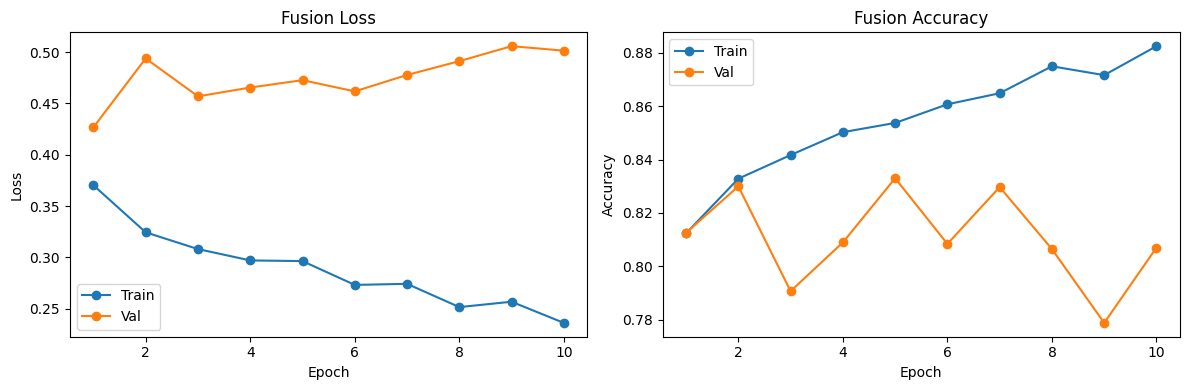

In [8]:
epochs = np.arange(1, EPOCHS + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax[0].plot(epochs, train_loss_hist, marker="o", label="Train")
ax[0].plot(epochs, val_loss_hist,   marker="o", label="Val")
ax[0].set_title("Fusion Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy curves
ax[1].plot(epochs, train_acc_hist, marker="o", label="Train")
ax[1].plot(epochs, val_acc_hist,   marker="o", label="Val")
ax[1].set_title("Fusion Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

### Evaluation and confusion matrix


--- MULTIMODAL FUSION VALIDATION RESULTS ---
Val Accuracy: 80.70%
Val F1 Score: 0.8641
Val ROC AUC:  0.8913


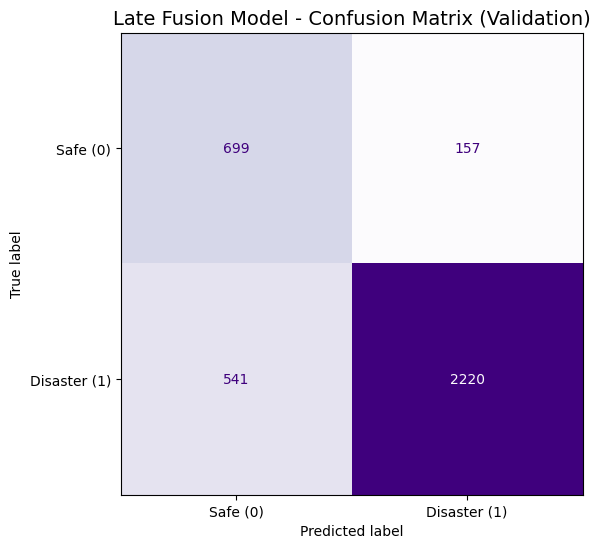

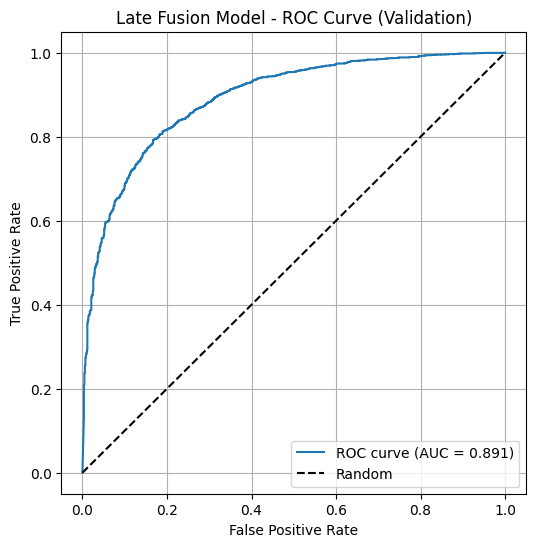

In [9]:
val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)

val_f1  = f1_score(val_true, val_preds, average="binary")
val_auc = roc_auc_score(val_true, val_probs)

print("\n--- MULTIMODAL FUSION VALIDATION RESULTS ---")
print(f"Val Accuracy: {val_acc * 100:.2f}%")
print(f"Val F1 Score: {val_f1:.4f}")
print(f"Val ROC AUC:  {val_auc:.4f}")

# Build confusion matrix
cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Safe (0)", "Disaster (1)"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Purples", ax=ax, colorbar=False)
plt.title("Late Fusion Model - Confusion Matrix (Validation)", fontsize=14)
plt.grid(False)
plt.show()

# Build ROC
fpr, tpr, _ = roc_curve(val_true, val_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {val_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Late Fusion Model - ROC Curve (Validation)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()